In [ ]:
#Opakovane testovanie

>>> Dosiahnutých 10 signifikantných výsledkov.


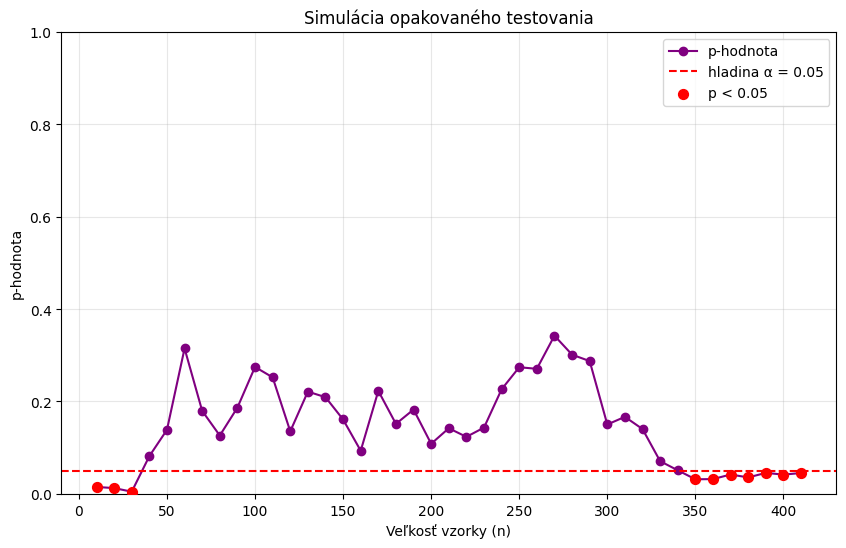


 Tabuľka signifikancie
     n  p-hodnota    BF01 Interpretácia
0   10     0.0149  0.1137    Podpora H1
1   20     0.0126  0.1992    Podpora H1
2   30     0.0047  0.1012    Podpora H1
3  350     0.0316  2.6219    Podpora H0
4  360     0.0320  2.6871    Podpora H0
5  370     0.0419  3.4323    Podpora H0
6  380     0.0356  3.0254    Podpora H0
7  390     0.0455  3.7724    Podpora H0
8  400     0.0417  3.5488    Podpora H0
9  410     0.0452  3.8456    Podpora H0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, norm
import sys
import os

sys.path.append(os.path.abspath(".."))
import settings

# načítanie dát
def load_file(file_path):
    return pd.read_sas(file_path, format='xport')

def merge_files(file1, file2):
    return pd.merge(file1, file2[['SEQN','RIDAGEYR','RIAGENDR']], on='SEQN', how='left')

def calculate_bf01(t_stat, n1, n2):
    if abs(t_stat) < 1e-5: return 1.0
    # stupne volnosti
    df = n1 + n2 - 2
    if df <= 0: return 1.0
    
    # aproximácia pre bayesov faktor
    bf10 = np.exp((t_stat**2 - np.log(df)) / 2)
    
    # Prepočet na BF01 
    bf01 = 1 / bf10
    return bf01

bmx = load_file(settings.bmx_path)
demo = load_file(settings.demo_path)
data = merge_files(bmx, demo)
data['gender'] = data['RIAGENDR'].map({1: "Muži", 2: "Ženy"})

menBMI = data[data['gender']=="Muži"]["BMXBMI"].dropna().values
womenBMI = data[data['gender']=="Ženy"]["BMXBMI"].dropna().values

# Náhodné premiešanie poradia dát
np.random.shuffle(menBMI)
np.random.shuffle(womenBMI)

# parametre simulácie
step = 10
p_threshold = 0.05
max_significant = 10
significant_count = 0

p_values = []
sample_sizes = []
results = []

# postupné testovanie
for n in range(step, min(len(menBMI), len(womenBMI)), step):
    men_sample = menBMI[:n]
    women_sample = womenBMI[:n]
    
    if len(men_sample) < 3: continue

    p_shapiro_m = shapiro(men_sample)[1]
    p_shapiro_w = shapiro(women_sample)[1]
    p_levene = levene(men_sample, women_sample)[1]

    if p_shapiro_m > 0.05 and p_shapiro_w > 0.05:
        if p_levene > 0.05:
            t_stat, p_val = ttest_ind(men_sample, women_sample, equal_var=True)
            test_used = "t-test"
        else:
            t_stat, p_val = ttest_ind(men_sample, women_sample, equal_var=False)
            test_used = "Welch t-test"
    else:
        u_stat, p_val = mannwhitneyu(men_sample, women_sample, alternative='two-sided')
        test_used = "Mann-Whitney U"
        
        t_stat = norm.ppf(1 - p_val/2) if p_val > 0 else 10

    # výpočet bayesovho faktora
    bf01 = calculate_bf01(t_stat, len(men_sample), len(women_sample))

    p_values.append(p_val)
    sample_sizes.append(n)
    
    results.append({
        "n": n,
        "p-hodnota": round(p_val, 4),
        "BF01": round(bf01, 4),
        "Test": test_used,
        "Interpretácia": "Podpora H0" if bf01 > 1 else "Podpora H1",
        "Signifikantné": "Áno" if p_val < p_threshold else "Nie"
    })

    if p_val < p_threshold:
        significant_count += 1
        if significant_count >= max_significant:
            print(f">>> Dosiahnutých {max_significant} signifikantných výsledkov.")
            break

# vizualizácia
plt.figure(figsize=(10,6))
plt.plot(sample_sizes, p_values, marker='o', linestyle='-', color='purple', label='p-hodnota')
plt.axhline(p_threshold, color='red', linestyle='--', label='hladina \u03B1 = 0.05')

sig_indices = [i for i, p in enumerate(p_values) if p < p_threshold]
if sig_indices:
    plt.scatter([sample_sizes[i] for i in sig_indices], [p_values[i] for i in sig_indices],
                color='red', s=50, zorder=5, label='p < 0.05')

plt.title("Simulácia opakovaného testovania")
plt.xlabel("Veľkosť vzorky (n)")
plt.ylabel("p-hodnota")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("phacking_bmi_simulation.png", dpi=300, bbox_inches="tight")
plt.show()

# spracovanie výsledkov
df_results = pd.DataFrame(results)
df_significant = df_results[df_results["Signifikantné"] == "Áno"].reset_index(drop=True)

if df_significant.empty:
    print("\n>>> Žiadne signifikantné výsledky neboli nájdené.")
else:
    print("\n Tabuľka signifikancie")
    
    print(df_significant[['n', 'p-hodnota', 'BF01', 'Interpretácia']].head(15))
    
    df_significant.head(10).to_csv("bayes_vs_pvalue_table.csv", index=False)

Pri forme p-hackingu - opakované testovanie výskumník testuje postupne zbierané dáta a zastaví zber v momente ako dosiahne štatisticky významný výsledok. Keďže pracujem už s nazbieraným datasetom, túto formu p-hackingu demonštrujem simuláciou na našom datasete. Testujem časti datasetu a postupne k nemu pridávam viac a viac dát (krok je nastavený na 20). Zakaždým zisťujem či dáta sú normálne rozdelené, či majú rovnaký rozptyl a podľa toho sa vyberie test, ktorý sa použije. V momente ako dosiahnem štatisticky výynamný výsledok, teda keď p-hodnota dosiahne hodnotu <= 0,05, zastavím testovanie a vypíšem a vykreslím výsledky.

In [3]:
pip install pingouin

     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     ------------------------------ --------- 30.7/40.8 kB 1.4 MB/s eta 0:00:01
     -------------------------------------- 40.8/40.8 kB 985.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/204.0 kB ? eta -:--:--
   ---------------------------------------- 204.0/204.0 kB 6.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.4 MB 10.9 MB/s eta 0:00:01
   ----------------------------- ---------- 1.1/1.4 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 10.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/95.8 kB ? eta -:--:--
   ---------------------------------------- 95.8/95.8 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.0
    Uninstalling packaging-24.0:
      Successfully uninstalled packaging-24.0
Note: yo


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
